In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
import numpy as np
import time

import os
import re
import math
import numpy as np
import pandas as pd
import cv2
from configparser import ConfigParser
from glob import glob # 파일 경로를 패턴으로 검색해 리스트로 가져오는 함수

from PIL import Image


In [3]:
class WheelSafeSlopeDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "img_path"]
        label = self.df.loc[idx, "label_deg"]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(label, dtype=torch.float32)

        return img, label

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

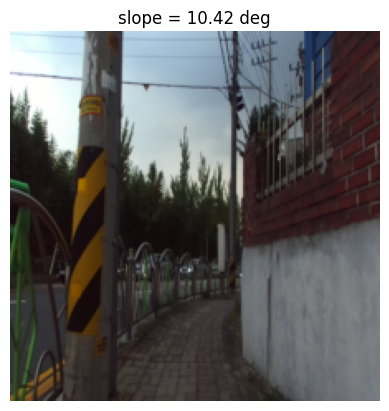

In [5]:
train_datasets = WheelSafeSlopeDataset(
    "../dl_datas/wheel_safe_dataset.csv",
    transform=transform
)

import matplotlib.pyplot as plt

img, label = train_datasets[0]

plt.imshow(img.permute(1,2,0))
plt.title(f"slope = {label:.2f} deg")
plt.axis("off")
plt.show()